# Trace AI Agent Decisions with BigQuery Property Graphs

## Introduction


*BigQuery property graphs, BigQuery Conversational Analytics, and the BigQuery Agent Analytics SDK are currently in Preview on Google Cloud. The BigQuery Agent Analytics Plugin is Generally Available (GA). Examples in this codelab use synthetic data.*

As autonomous AI agents take on more operational responsibilities (evaluating loan applications, managing marketing budgets, approving access requests), organizations must be able to audit and explain their decisions. Reconstructing the exact context, alternatives considered, and final rationale of an agent's decision is essential for compliance, risk management, and operational trust.

This codelab uses the BigQuery Agent Analytics SDK to transform raw agent event logs into an **Agent Context Graph** — a queryable BigQuery property graph of agent decisions — on a schedule, without any external graph database or ETL pipeline.

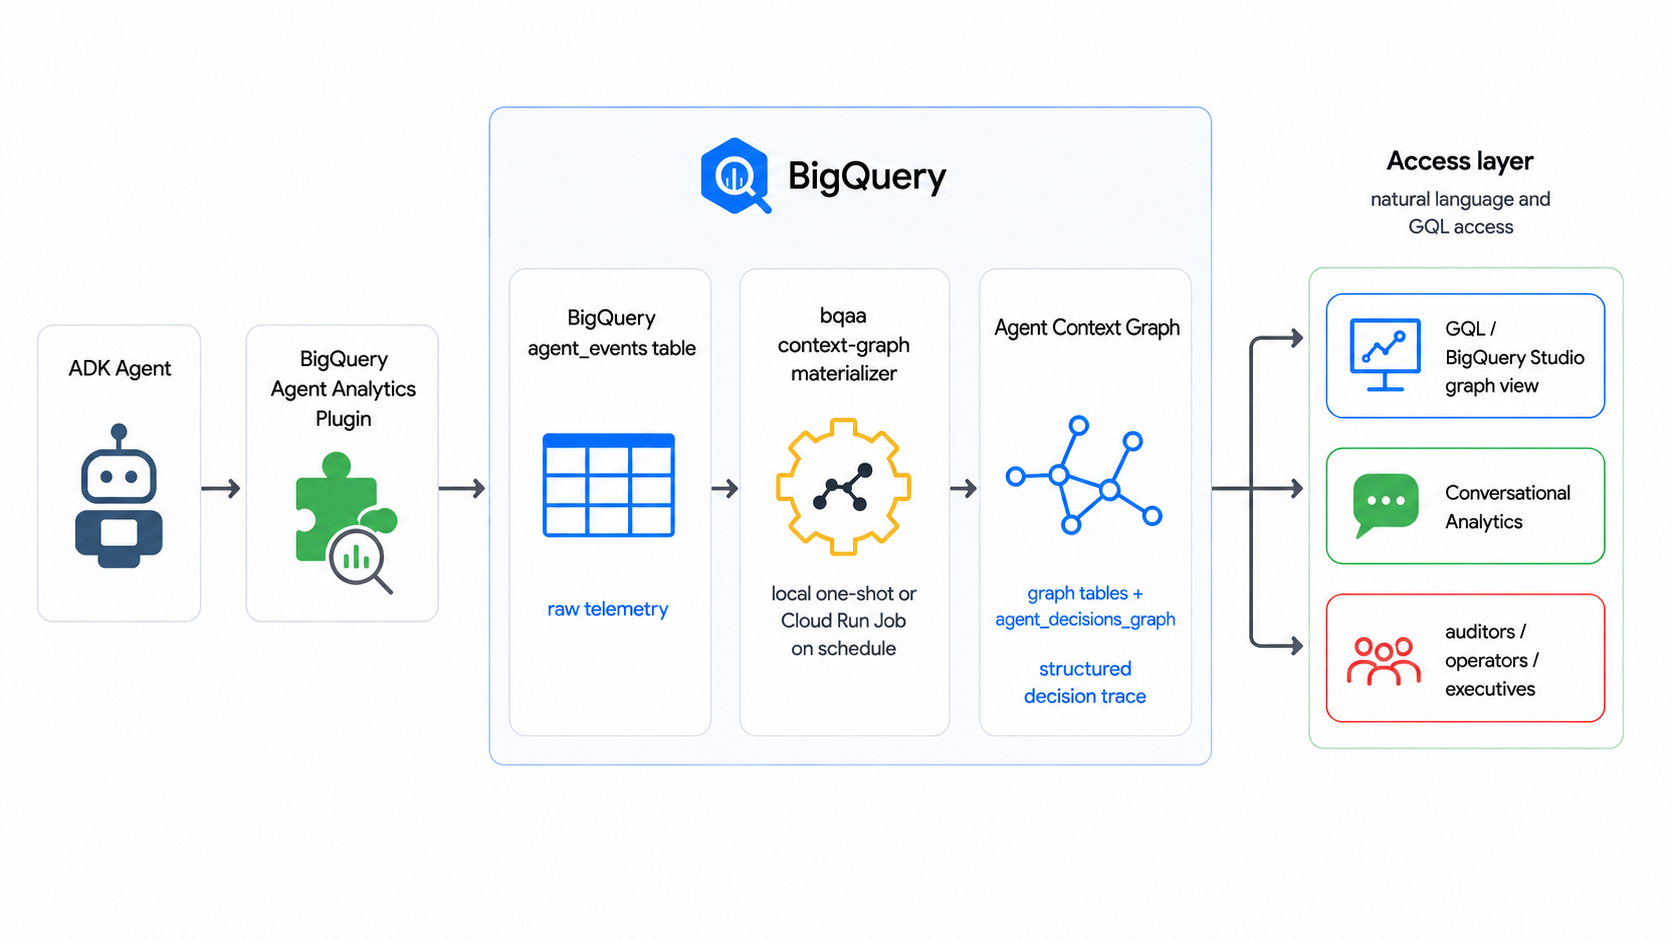

### What you'll build

- An Agent Context Graph (a BigQuery property graph) that models a generic agent decision flow: a request comes in, the agent weighs options, an outcome is committed.
- A populated `agent_events` table with a synthetic event corpus.
- A working `bqaa context-graph` run that fills the graph from those events.
- A one-shot replay (backfill) of a past time window — useful when events arrived during an outage — without disturbing the regular refresh schedule.
- An audit-style GQL query that traces a single decision end-to-end.

### What you'll learn

- How the BigQuery Agent Analytics Plugin writes to `agent_events`.
- How a context graph is defined by two declarative artifacts (table DDL + a `CREATE PROPERTY GRAPH` schema) — and why no separate ontology or binding file is required.
- How to run `bqaa context-graph` against a property graph.
- How to query a BigQuery property graph in GQL.
- The production-grade capabilities the SDK supports for enterprise deployments.

### What you'll need

- A Google Cloud project with billing enabled.
- Owner or Editor role on that project. You will create a BigQuery dataset and grant IAM.
- The `gcloud` CLI installed and authenticated, or access to Cloud Shell.
- Python 3.10 or newer.
- Familiarity with BigQuery SQL. GQL knowledge is not required.

This codelab is for developers of all levels, including those new to property graphs.

The resources created in this codelab cost very little, and the final step tears everything down so you are not billed for an idle dataset.

**Estimated duration:** This codelab takes approximately 42 minutes to complete.

## Before you begin


#### Pick a project and region

Open Cloud Shell or a local terminal:

In [ ]:
import os

# Change these three lines to match your GCP environment.
PROJECT_ID = "your-project-id"
REGION     = "us-central1"
DATASET    = "agent_analytics_demo"

# Export to the shell environment so the !-prefixed cells below see them.
os.environ["PROJECT_ID"] = PROJECT_ID
os.environ["REGION"]     = REGION
os.environ["DATASET"]    = DATASET

print(f"PROJECT_ID = {PROJECT_ID}")
print(f"REGION     = {REGION}")
print(f"DATASET    = {DATASET}")

In [ ]:
# Authenticate against your GCP project.
# In colab.research.google.com this prompts for an account interactively.
# In Vertex AI Colab Enterprise the project service account auth is used
# automatically.
try:
    from google.colab import auth
    auth.authenticate_user()
    print("Authenticated via google.colab.auth.")
except ImportError:
    print(
        "google.colab not available; assuming gcloud Application Default"
        " Credentials are already configured."
    )

!gcloud config set project $PROJECT_ID

The single `DATASET` variable holds both the raw `agent_events` table and the materialized graph tables. Using one dataset keeps the codelab simple. Production deployments often split events and graph into separate datasets so IAM can be granted narrowly per dataset.

#### Enable the required APIs

**Run the following command** to enable the APIs this codelab uses:

In [ ]:
!gcloud services enable      bigquery.googleapis.com      aiplatform.googleapis.com      --project="$PROJECT_ID"

The `aiplatform.googleapis.com` API is required because the SDK's default extraction path calls BigQuery's `AI.GENERATE` function. If you later switch to deterministic extraction with `--extraction-mode=compiled-only`, this API is no longer needed.

#### Create the BigQuery dataset

**Create the dataset** that will hold both the raw `agent_events` table and the materialized graph tables:

In [ ]:
!bq --location=US mk --dataset "$PROJECT_ID:$DATASET"

You should see a success message:

```console
Dataset 'your-project-id:agent_analytics_demo' successfully created.
```

If the dataset already exists, the command errors harmlessly. Leave it in place.

## Install the SDK


Set up a Python virtual environment and **install the SDK** from PyPI:

In [ ]:
# Install the SDK and the BigQuery client library directly into the
# notebook runtime. The local-terminal codelab path creates a venv
# first; in Colab the runtime is already isolated, so a plain pip
# install is enough.
!pip install --quiet --upgrade bigquery-agent-analytics google-cloud-bigquery

**Verify the install:**

In [ ]:
!bqaa context-graph --help | head -8

You should see the CLI banner.

> **Migrating from `bqaa-materialize-window`?** The old standalone command still works and accepts the same flags — it now prints a one-line deprecation notice on stderr and forwards to the same handler. Existing scripts and Cloud Run Jobs keep running while you migrate.

#### Authenticate

If you are on a workstation:


Cloud Shell users can skip this step; credentials are already configured. (In Colab the configuration cell above already handled this via `google.colab.auth`.)

## Get the codelab artifacts


The codelab needs just two ready-to-use artifacts: the **table DDL** (the physical graph tables) and the **property-graph schema** (`CREATE PROPERTY GRAPH`). You do not author either yourself; the codelab uses them as-is, and the [README in the artifacts folder](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/blob/main/examples/context_graph/codelab/README.md) explains how to adapt them for your own decision domain.

The property-graph schema is the single source of truth for *what* the graph contains. You apply it to BigQuery once; from then on the **deployed graph itself is the contract**: `bqaa context-graph` reads the graph's definition back from BigQuery's `INFORMATION_SCHEMA.PROPERTY_GRAPHS` (plus your table schemas) to figure out which entities and relationships to extract and where to write them — so you do **not** need to write a separate ontology or binding file, and no SQL file is ever passed to the materializer.

This codelab is self-contained: the cell below writes the two artifacts into a working directory, so there is nothing to download. They are the same files shipped in [`examples/context_graph/codelab/`](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph/codelab).

In [ ]:
# This codelab is self-contained: rather than downloading files, this
# cell writes the two artifacts into a working directory. They are
# identical to the files in examples/context_graph/codelab/.
from pathlib import Path

work = Path.home() / "bqaa-codelab"
work.mkdir(exist_ok=True)

artifacts = {
    "table_ddl.sql": r"""-- Node and edge table DDL for the BQAA codelab.
--
-- The materializer writes into these tables on every run.
-- ``session_id`` and ``extracted_at`` are SDK metadata columns the
-- materializer fills automatically; they are required on every
-- bound table.
--
-- Apply with:
--   envsubst < table_ddl.sql | bq query --use_legacy_sql=false
--
-- Required shell variables:
--   PROJECT_ID  : your GCP project ID
--   DATASET     : the BigQuery dataset that holds both raw agent_events
--                 and the materialized graph tables
CREATE TABLE IF NOT EXISTS `${PROJECT_ID}.${DATASET}.decision_request` (
  request_id STRING, request_text STRING, requested_at TIMESTAMP,
  session_id STRING, extracted_at TIMESTAMP
);
CREATE TABLE IF NOT EXISTS `${PROJECT_ID}.${DATASET}.decision_option` (
  option_id STRING, option_label STRING, confidence FLOAT64,
  session_id STRING, extracted_at TIMESTAMP
);
CREATE TABLE IF NOT EXISTS `${PROJECT_ID}.${DATASET}.decision_outcome` (
  outcome_id STRING, status STRING, rationale STRING, decided_at TIMESTAMP,
  session_id STRING, extracted_at TIMESTAMP
);
CREATE TABLE IF NOT EXISTS `${PROJECT_ID}.${DATASET}.evaluates_option` (
  request_id STRING, option_id STRING,
  session_id STRING, extracted_at TIMESTAMP
);
CREATE TABLE IF NOT EXISTS `${PROJECT_ID}.${DATASET}.resulted_in` (
  request_id STRING, outcome_id STRING,
  session_id STRING, extracted_at TIMESTAMP
);
""",
    "property_graph.sql": r"""-- Property-graph DDL for the BQAA codelab.
--
-- Models a generic agent decision flow:
--   DecisionRequest -> evaluatesOption -> DecisionOption
--   DecisionRequest -> resultedIn       -> DecisionOutcome
--
-- Apply with:
--   envsubst < property_graph.sql | bq query --use_legacy_sql=false
--
-- Required shell variables:
--   PROJECT_ID  : your GCP project ID
--   DATASET     : the BigQuery dataset that holds both raw agent_events
--                 and the materialized graph tables (single-dataset shape)
CREATE OR REPLACE PROPERTY GRAPH `${PROJECT_ID}.${DATASET}.agent_decisions_graph`
  NODE TABLES (
    `${PROJECT_ID}.${DATASET}.decision_request` AS decision_request
      KEY (request_id)
      LABEL DecisionRequest PROPERTIES (request_id, request_text, requested_at),
    `${PROJECT_ID}.${DATASET}.decision_option` AS decision_option
      KEY (option_id)
      LABEL DecisionOption PROPERTIES (option_id, option_label, confidence),
    `${PROJECT_ID}.${DATASET}.decision_outcome` AS decision_outcome
      KEY (outcome_id)
      LABEL DecisionOutcome PROPERTIES (outcome_id, status, rationale, decided_at)
  )
  EDGE TABLES (
    `${PROJECT_ID}.${DATASET}.evaluates_option` AS evaluates_option
      KEY (request_id, option_id)
      SOURCE KEY (request_id) REFERENCES decision_request (request_id)
      DESTINATION KEY (option_id) REFERENCES decision_option (option_id)
      LABEL evaluatesOption,
    `${PROJECT_ID}.${DATASET}.resulted_in` AS resulted_in
      KEY (request_id, outcome_id)
      SOURCE KEY (request_id) REFERENCES decision_request (request_id)
      DESTINATION KEY (outcome_id) REFERENCES decision_outcome (outcome_id)
      LABEL resultedIn
  );
""",
}
for name, body in artifacts.items():
    (work / name).write_text(body)

print("Wrote:", ", ".join(sorted(artifacts)))

The cell writes these two artifacts:

```
property_graph.sql  table_ddl.sql
```

The decision flow they describe has three node types and two heterogeneous edges:

```
DecisionRequest --[evaluatesOption]--> DecisionOption
              \--[resultedIn]--------> DecisionOutcome
```

`DecisionRequest` is the question the agent received. `DecisionOption` is one alternative the agent considered. `DecisionOutcome` records the committed choice and the rationale.

> **Advanced: bring your own ontology + binding.** Schema-derived mode covers the common case. When you need finer control — human-readable descriptions to steer the AI extraction prompt, entity inheritance, derived (computed) properties, or column renames — author an explicit `ontology.yaml` + `binding.yaml` and pass `--ontology`/`--binding` instead of `--graph`. The [context-graph example](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph) ships a complete checked-in pair as a reference.

## Apply the property graph schema


The materializer writes into BigQuery tables, so they must exist before the first run. **Apply the table DDL first, then the property-graph DDL** (the property graph references those tables, and BigQuery rejects a `CREATE PROPERTY GRAPH` that points at tables that do not yet exist):

In [ ]:
!cd ~/bqaa-codelab && \
    envsubst < table_ddl.sql      | bq query --use_legacy_sql=false && \
    envsubst < property_graph.sql | bq query --use_legacy_sql=false

You should see five `CREATE TABLE` results and one `CREATE PROPERTY GRAPH` result. The DDL is idempotent; you can re-run it safely.

That is the only schema work you do — and the only time the SQL files are used. BigQuery now records your graph's definition, and `bqaa context-graph` reads it back from `INFORMATION_SCHEMA.PROPERTY_GRAPHS` by name, so there is no separate binding file to render and no SQL file to pass to the materializer. What you query with GQL and what gets materialized can never drift apart: they are the same deployed graph.

## Generate sample agent events


In production, the BigQuery Agent Analytics Plugin captures events automatically as your ADK agent runs:

```python
from google.adk.plugins import BigQueryAgentAnalyticsPlugin

plugin = BigQueryAgentAnalyticsPlugin(
    project_id="your-project-id",
    dataset_id="agent_analytics_demo",
)
runner = Runner(agent=root_agent, plugins=[plugin])
```

For this codelab you use a small synthetic event generator that writes the same shape of rows directly to `agent_events`. Run it:

In [ ]:
!pip install google-cloud-bigquery && \
    cd ~/bqaa-codelab && \
    bqaa seed-events      --project-id "$PROJECT_ID"      --dataset-id "$DATASET"      --sessions 5

The command prints a JSON report. For 5 sessions you should see `"events_generated": 30`, `"events_inserted": 30`, and `"ok": true`.

Preview the corpus at a glance — how many sessions, how many events, and the time range they span — in one row:

In [ ]:
!bq query --use_legacy_sql=false      "SELECT COUNT(DISTINCT session_id) AS sessions, COUNT(*) AS events, MIN(timestamp) AS earliest_event, MAX(timestamp) AS latest_event FROM \`$PROJECT_ID.$DATASET.agent_events\`"

For the default 5-session run this shows 5 sessions and 30 events spanning a few minutes. (Seed the realistic scenario below and the same query reports ~100 sessions across roughly three days.)

Verify the events landed:

In [ ]:
!bq query --use_legacy_sql=false      "SELECT event_type, COUNT(*) AS n FROM \`$PROJECT_ID.$DATASET.agent_events\` GROUP BY event_type ORDER BY n DESC"

You should see 25 `TOOL_COMPLETED` rows and 5 `AGENT_COMPLETED` rows (each session emits one `submit_request`, three `evaluate_option`, one `commit_outcome`, and one closing `AGENT_COMPLETED` — five tool events plus one agent terminator per session). The `AGENT_COMPLETED` rows are the session terminators that the materializer keys on for terminal-event detection.

#### Optional: realistic-scale data

The 5-session corpus above is intentionally tiny so the first run is fast. When you want production-shaped data — multiple agents and users spread over several days, with failed, orphaned, and truncated sessions — use the `decision-realistic` scenario. It defaults to 100 sessions over a 72-hour window; the first-run path above is unchanged.

In [ ]:
!bqaa seed-events      --project-id "$PROJECT_ID"      --dataset-id "$DATASET"      --scenario decision-realistic      --sessions 100      --seed 42

The JSON report's `session_outcome_counts` shows the mix — roughly `{"success": 70, "failed": 10, "orphaned": 10, "truncated": 10}`.

> Once you have this realistic corpus, the [Conversational Analytics-first guide](../guides/conversational-analytics-first.md) shows how to ask it in plain English ("which requests weighed a low-confidence option?") before dropping to GQL.

Confirm the outcome distribution by classifying each session from its rows (orphaned = no `AGENT_COMPLETED`; failed = `AGENT_COMPLETED` with `status = 'error'`; truncated = any row with `is_truncated = true`; otherwise success). A first pass classifies each session, then a second aggregates per outcome:

In [ ]:
!bq query --use_legacy_sql=false      "WITH per_session AS (SELECT session_id, CASE WHEN COUNTIF(event_type = 'AGENT_COMPLETED') = 0 THEN 'orphaned' WHEN COUNTIF(event_type = 'AGENT_COMPLETED' AND status = 'error') > 0 THEN 'failed' WHEN COUNTIF(is_truncated) > 0 THEN 'truncated' ELSE 'success' END AS outcome FROM \`$PROJECT_ID.$DATASET.agent_events\` GROUP BY session_id) SELECT outcome, COUNT(*) AS sessions FROM per_session GROUP BY outcome ORDER BY outcome"

You should see roughly 70 success, 10 failed, 10 orphaned, and 10 truncated (plus the 5 successful sessions from the first-run corpus if you seeded that earlier in the same dataset).

The 10 orphaned sessions never emitted `AGENT_COMPLETED`, so the default `bqaa context-graph` run skips them (it materializes only terminal-event-closed sessions). To surface them as `session_orphaned` instead of silently retrying forever, add `--max-session-age-hours` when you materialize — see the orphan-watchdog discussion later in this codelab.

> This scenario spreads its sessions across a 72-hour window on purpose. The *Materialize the decision graph* walkthrough below uses `--lookback-hours 24` and is written for the small 5-session first-run corpus, so its exact counts assume you have *not* run this optional step. If you did, that is the intended lesson: a 24-hour materialization window picks up only the recent slice of a multi-day backlog — widen `--lookback-hours` (or backfill) to capture the older sessions.

## Materialize the decision graph


`bqaa context-graph` reads the raw `agent_events`, then **derives what to extract directly from your deployed graph**: it reads the `CREATE PROPERTY GRAPH` definition you applied in *Apply the property graph schema* back from BigQuery's `INFORMATION_SCHEMA.PROPERTY_GRAPHS`, joins it with the schemas of the tables it references, works out the entities, relationships, and column types, and populates the graph tables. Point it at the deployed graph by name with `--graph` — no SQL file, no separate ontology or binding file.

**Run the materializer** locally:

In [ ]:
!bqaa context-graph      --project-id "$PROJECT_ID"      --dataset-id "$DATASET"      --graph agent_decisions_graph      --lookback-hours 24      --format json

You should see a structured JSON report:

```json
{
  "run_id": "...",
  "sessions_discovered": 5,
  "sessions_materialized": 5,
  "sessions_failed": 0,
  "rows_materialized": {
    "DecisionRequest": 5,
    "DecisionOption": 15,
    "DecisionOutcome": 5
  },
  "ok": true
}
```

`ok: true` indicates the materializer found five completed sessions, extracted the decision flow from each via `AI.GENERATE`, and wrote the corresponding rows into the graph tables.

If you see `ok: false` with `error_code = "empty_extraction"`, the most common cause is that the `aiplatform.googleapis.com` API has not propagated yet, or your account is missing `roles/aiplatform.user`. Wait a minute and retry, or grant the role:

```bash
USER_EMAIL=$(gcloud auth list --filter=status:ACTIVE --format="value(account)")
gcloud projects add-iam-policy-binding "$PROJECT_ID" \
    --member="user:$USER_EMAIL" --role="roles/aiplatform.user"
```

Verify the graph has rows:

In [ ]:
!bq query --use_legacy_sql=false      "SELECT COUNT(*) AS n FROM \`$PROJECT_ID.$DATASET.decision_request\`"

You should see five rows.

#### Two ways to extract decisions from events

The materializer offers two extraction paths. Pick the one that matches your workload:

- **Default extraction.** The easiest path. Uses BigQuery's `AI.GENERATE` to read event content and infer entities and relationships. Works against any event shape with no extra code. This is what the codelab uses.
- **Deterministic extraction** (`--extraction-mode=compiled-only`). The lower-cost, audit-friendly path. Uses a small Python reference extractor you write once for your ontology. No Vertex AI calls, no per-token charges, fully reproducible output. Production deployments choose this when cost predictability or strict reproducibility matters.

> **Tip:** Deterministic extraction is also the path for regulated workloads that need to remove the Vertex AI dependency from the runtime service account entirely. See the [production deployment guide](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph/periodic_materialization) for the IAM details.

## Query the decision trace


With the graph populated, you can answer the audit question directly. Take a concrete one: *"For each request, what options did the agent weigh, and how did it resolve?"* In GQL that is a single traversal across the request, its options, and its outcome. **Save the following as `traversal.sql`:**

```sql
SELECT *
FROM GRAPH_TABLE (
  ${DATASET}.agent_decisions_graph
  MATCH
    (req:DecisionRequest) -[eo:evaluatesOption]-> (opt:DecisionOption),
    (req)                 -[ri:resultedIn]->      (out:DecisionOutcome)
  COLUMNS (
    req.request_id   AS request,
    req.request_text AS question,
    opt.option_label AS considered,
    opt.confidence   AS score,
    out.status       AS outcome,
    out.rationale    AS rationale
  )
);
```

Run it:

In [ ]:
# Run the same GQL traversal from the notebook. We embed the SQL in a
# Python f-string so the ${DATASET} placeholder is filled in by the
# notebook's PROJECT_ID / DATASET variables, and we display the result
# as a pandas DataFrame for in-cell readability.
DATASET = os.environ["DATASET"]
PROJECT_ID = os.environ["PROJECT_ID"]
traversal_sql = f"""
SELECT *
FROM GRAPH_TABLE (
  {DATASET}.agent_decisions_graph
  MATCH
    (req:DecisionRequest) -[eo:evaluatesOption]-> (opt:DecisionOption),
    (req)                 -[ri:resultedIn]->      (out:DecisionOutcome)
  COLUMNS (
    req.request_id   AS request,
    req.request_text AS question,
    opt.option_label AS considered,
    opt.confidence   AS score,
    out.status       AS outcome,
    out.rationale    AS rationale
  )
)
ORDER BY request, score DESC;
"""

from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)
results_df = client.query(traversal_sql).to_dataframe()
results_df

You should see fifteen rows: three options per request, five requests. Each row shows the request, the option the agent considered, its confidence score, the final outcome, and the rationale.

For a single decision's full picture, filter by `request_id` to get the row set an audit team needs: the question that came in, the options that were weighed (with scores), and the rationale that was committed.

#### Visualize the graph in BigQuery Studio

BigQuery Studio can also render the property graph visually. Open the `agent_decisions_graph` in the BigQuery console and run a path query — for example, `GRAPH ${DATASET}.agent_decisions_graph MATCH p = (a)-[e]->(b) RETURN TO_JSON(p) AS path_json` — then switch the results pane to the **Graph** tab to see the decision web. With the realistic-scale corpus this gives you a visual map of requests, options, and outcomes:

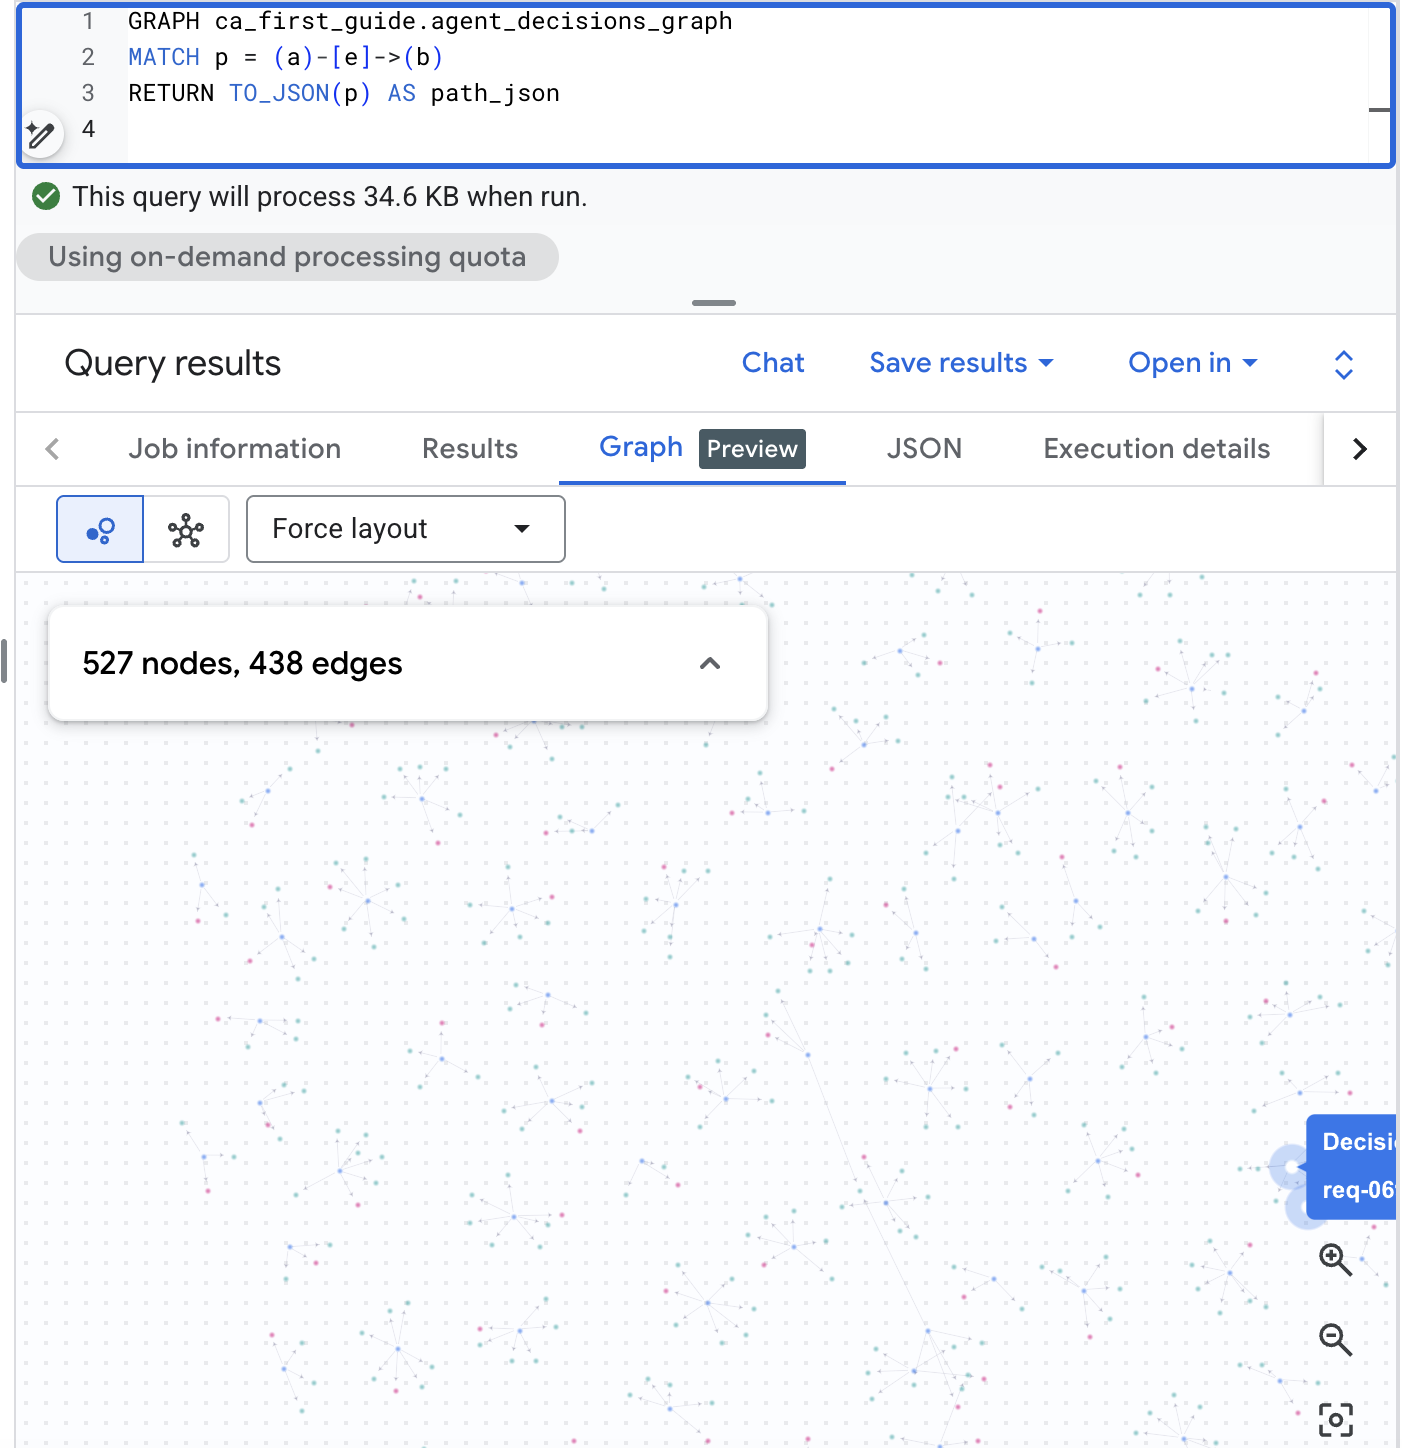

#### Ask the same question in plain English

Not every audit reader writes GQL. With **BigQuery Conversational Analytics** (Preview), your compliance team can ask the same kind of question in natural language and get back a structured answer card — no query syntax, no joins to learn.

Register the `agent_decisions_graph` (along with the `agent_events` and decision tables) as a Conversational Analytics data source, then ask the audit question directly:

**Audit question (plain English):** *"Which requests never reached a committed outcome?"*

Conversational Analytics reasons over the graph, writes the SQL for you, and replies in plain English with a supporting table — here, that every recorded request reached a committed outcome:

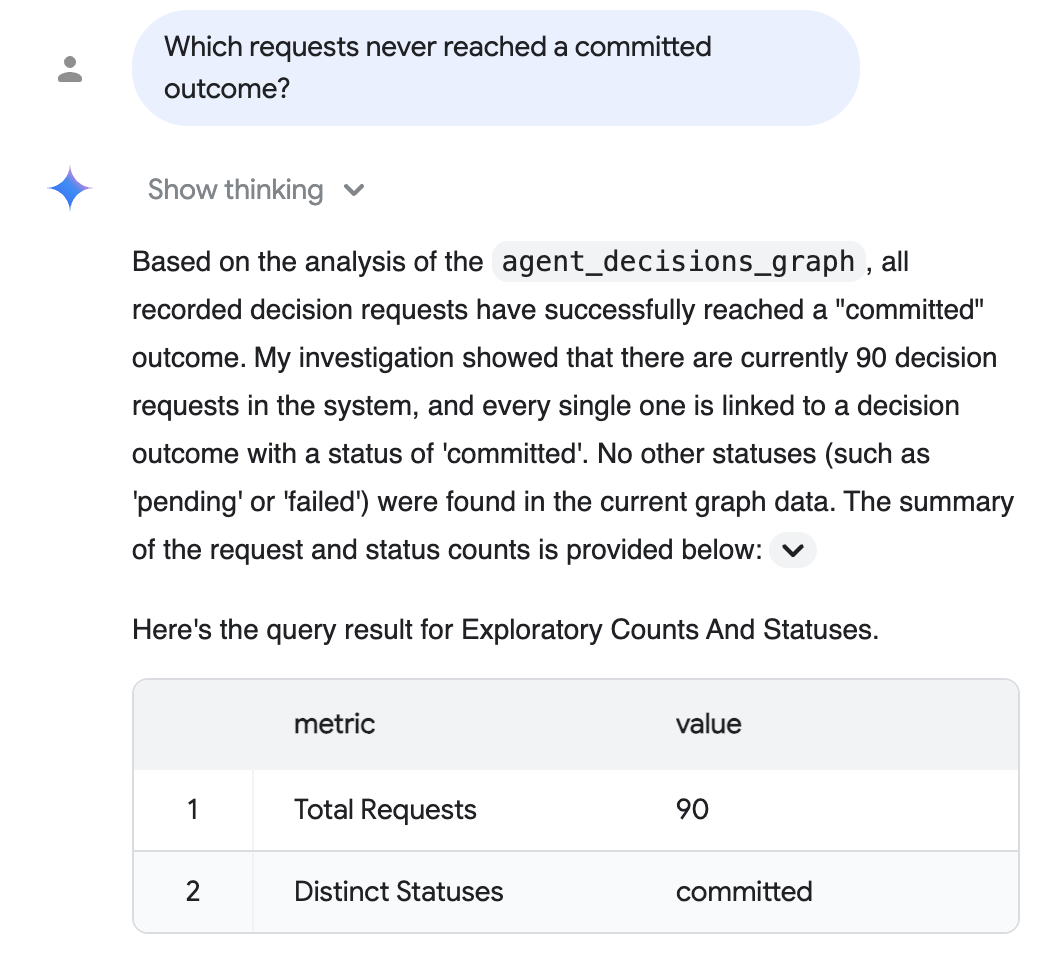

> The reply above reflects the realistic-scale corpus from the optional *realistic-scale data* step (90 materialized requests, all committed). Your exact numbers depend on which corpus you seeded — the default 5-session run shows five.

See the [Conversational Analytics documentation](https://cloud.google.com/bigquery/docs/conversational-analytics) for setup.

## Replay a past window


Sometimes you need to re-process a past time window: events arrived during an outage, a schema change requires re-extraction, or an audit team asks about a specific historical period. Backfill mode lets you do that **without disturbing the regular refresh schedule** — the replay runs against a fixed start-and-end window you choose, and its progress is tracked separately from the regular refresh.

In a real recovery you would point the backfill at the window where the missed events actually arrived. For this codelab, run a backfill against an **empty historical window** (eight to nine hours ago, before you seeded any events). The replay finishes immediately because there is nothing to materialize, which lets you see the audit trail it produces without re-touching the rows you already wrote in *Materialize the decision graph*.

In [ ]:
import datetime, os
now = datetime.datetime.now(datetime.timezone.utc)
os.environ["FROM"] = (now - datetime.timedelta(hours=9)).strftime("%Y-%m-%dT%H:%M:%SZ")
os.environ["TO"]   = (now - datetime.timedelta(hours=8)).strftime("%Y-%m-%dT%H:%M:%SZ")
print(f"Backfill window FROM = {os.environ['FROM']}")
print(f"Backfill window TO   = {os.environ['TO']}")

!bqaa context-graph \
    --project-id "$PROJECT_ID" \
    --dataset-id "$DATASET" \
    --graph agent_decisions_graph \
    --lookback-hours 1 \
    --backfill --from "$FROM" --to "$TO" \
    --state-key-suffix codelab_backfill_demo \
    --format json

(The `date -u -d ...` form is GNU `date` on Linux and Cloud Shell; the `date -u -v-9H` form is BSD `date` on macOS. The `||` falls back to the macOS form if the GNU form fails.)

You should see a JSON report with `"sessions_materialized": 0` because the window you picked doesn't overlap with the events you seeded. Now inspect the audit trail this run wrote into the state table:

In [ ]:
!bq query --use_legacy_sql=false      "SELECT mode, scan_start, scan_end, sessions_materialized, ok       FROM \`$PROJECT_ID.$DATASET._bqaa_materialization_state\`       ORDER BY run_started_at DESC LIMIT 5"

You should see at least two rows: one from the steady-state materialization (`mode = 'steady'`) and one from this backfill (`mode = 'backfill'`). The two are independent — the backfill's progress is tracked separately, so it cannot disrupt the regular refresh.

> **How the isolation works (optional detail):** Each materializer run writes a row to the `_bqaa_materialization_state` table keyed by a `state_key` hash. Backfill mode mixes the `--state-key-suffix` you pass into that hash, so the backfill writes to a different `state_key` than the regular schedule. Same table, different rows, separate progress markers. Production operators query this table to confirm a catch-up actually ran.

## Production-grade capabilities


The local run you completed in *Materialize the decision graph* uses default behavior. Real deployments care about cost, reliability, and audit posture — the SDK supports each one out of the box.

**What you get by default:**

* **Every run leaves a clear audit trail.** Structured JSON logs go to Cloud Logging, and a per-run row lands in a state table inside your dataset — useful for alerting, dashboards, and answering "did the refresh actually happen?"
* **Transient failures retry automatically.** The materializer retries a small number of times (default two) before flagging a failure, so a slow query or a brief Vertex AI hiccup doesn't take down the run.
* **No double-counting.** Progress only advances on sessions that fully succeeded, so retrying a partially-failed run picks up exactly where it left off.

**What you opt into when you need it:**

* **Lower-cost, deterministic extraction** (`--extraction-mode=compiled-only`). Swaps the LLM-based extractor for a small reference-extractor module you write once. Removes the Vertex AI dependency and the per-token cost. Recommended for steady-state production workloads and any audit that requires reproducibility.
* **Catch stuck sessions** (`--max-session-age-hours`). If your agents sometimes fail to emit a terminal event, this flags long-running sessions as orphaned so operators can drain them — instead of the scheduled refresh silently retrying them forever.
* **Replay a past window** (`--backfill --from / --to`). You exercised this in *Replay a past window* above. The replay is tracked separately from the regular schedule so it cannot interfere with the live refresh.
* **Bound the per-run batch size** (`--max-sessions`). Useful when an upstream event spike threatens to overwhelm a single scan.

> **From "run this once" to "run this every six hours":** The SDK ships a deploy script and a Terraform module that wrap `bqaa context-graph` as a Cloud Run Job triggered by Cloud Scheduler, with least-privilege service accounts and the IAM grants the job needs. Follow the [scheduled Agent Context Graph deploy runbook](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/blob/main/docs/guides/scheduled-context-graph-deploy.md) to take *this* deployed graph to a scheduled deploy with the same `--graph` flow, or the [periodic-materialization deployment guide](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph/periodic_materialization) for the full IAM matrix and the explicit-ontology/binding path.

## Clean up


**Tear down what you created** so you do not get billed for an idle dataset:

In [ ]:
# UNCOMMENT TO RUN. This permanently deletes the dataset and everything
# in it (events, graph tables, state table). Left commented so a
# "Run all" pass does not tear down your work.
# !bq rm -r -f --dataset "$PROJECT_ID:$DATASET"

That single command removes the dataset, the agent events, the graph tables, and the state table together.

## Congratulations


Congratulations! You've turned raw agent event logs into a queryable Agent Context Graph in BigQuery and traced a single decision end-to-end, with no external graph database or ETL pipeline.

The same pattern applies wherever an agent makes consequential decisions: credit underwriting, prior authorization, marketing budget moves, procurement, customer service, and internal IT. To build your own decision graph, copy the codelab artifacts as a starting point, adapt the two declarative files (table DDL + the `CREATE PROPERTY GRAPH` schema) to your domain, and apply them to BigQuery — `bqaa context-graph --graph` reads the deployed graph and derives the rest. Reach for an explicit `ontology.yaml` + `binding.yaml` only when you need descriptions, inheritance, derived properties, or column renames.

#### What you've learned

- How to create a BigQuery dataset and apply a property-graph schema describing an agent decision domain.
- How to populate `agent_events` with a synthetic event corpus.
- How to run `bqaa context-graph` to extract a decision graph from those events.
- How to replay a past time window with backfill mode, separately from the regular refresh schedule.
- How to query the resulting graph in GQL and read the audit-style answer.

#### Reference docs

- [BigQuery Agent Analytics SDK repository](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK)
- [Codelab artifacts and adaptation guide](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph/codelab)
- [Periodic-materialization deployment guide](https://github.com/GoogleCloudPlatform/BigQuery-Agent-Analytics-SDK/tree/main/examples/context_graph/periodic_materialization): required APIs, IAM matrix, recommended schedules, Cloud Monitoring alert queries, and the Terraform module.
- [BigQuery property graphs documentation](https://cloud.google.com/bigquery/docs/reference/standard-sql/graph-intro) (Preview).
- [BigQuery Conversational Analytics documentation](https://cloud.google.com/bigquery/docs/conversational-analytics) (Preview).